# Replicating *Modular Dynamics of Financial Market Networks*

Silva, Comin, Peron, Rodrigues, Ye, Wilson, Hancock & Costa (2015) — [arXiv:1501.05040v3](https://arxiv.org/abs/1501.05040)

**This notebook runs what the paper says it ran and puts the result next to the paper's own figure.**
Nothing is added, corrected or extended.

**Every comparison is labelled.** Grey band = the paper's figure, lifted straight out of the PDF.
Blue band = ours, drawn from this run.

## The claim, in plain words

Each day, measure how similarly every pair of stocks moved over the last 30 days, keep the strongest 10%
of pairs as links, and you get one network per day. Find its **communities** — groups of stocks that
connect to each other more than to everyone else.

Now throw the network away and keep only two things: how big each community was, and how many links ran
between each pair of communities (the mixing matrix Π). Build a fresh random network from those numbers
alone. The paper's claim is that it looks like the real one — so the community structure carries almost
all the information.

To judge that you need a yardstick. The paper uses a second random network that keeps only each stock's
**number of links** and shuffles the rest. Anything that model already reproduces is explained by link
counts, not communities.

*Before running: needs `python-igraph` and `pyarrow`, both in `requirements.txt`.*

In [1]:
import json, os, random, sys, warnings
import numpy as np, pandas as pd
import igraph as ig
import matplotlib.pyplot as plt

ROOT = os.path.abspath(".")
sys.path.insert(0, ROOT); sys.path.insert(0, os.path.join(ROOT, "experiments"))
warnings.filterwarnings("ignore")

import exp_paper_only as P
from net.construct import (window_correlation, target_edge_count, threshold_window)
from net.communities import graph_from_pairs, MixingStore
from net.nullmodels import block_probabilities, community_graph, configuration_graph
from utils.crisis_dates import CRISES

# the paper's colours: inferred = navy, community = orange, degree = green
C_REAL, C_COMM, C_CONF = "#1f3f8f", "#e0801a", "#1f8f4a"
C_COMM_L, C_CONF_L     = "#f4b878", "#8fce9f"
BAND_P, BAND_O = "#7a828c", "#1f3f8f"
PFIG = os.path.join(ROOT, "docs", "paper_figs")

plt.rcParams.update({"figure.dpi": 110, "font.size": 8.5, "axes.grid": True,
                     "grid.alpha": .22, "axes.spines.top": False, "axes.spines.right": False})

LABEL = {"modularity": "Modularity", "path_length": "Average Path Length",
         "assortativity": "Assortativity", "transitivity": "Transitivity",
         "betweenness": "Average Betweenness", "clique_number": "Clique Number",
         "rich_club": "Rich-Club", "matching_index": "Average Match Index"}
MODEL = {"comm": "Community", "conf": "Degree dist."}


PNAME = {"fig3": "Fig. 3", "fig4": "Fig. 4", "fig5": "Fig. 5",
         "fig6_a": "Fig. 6a", "fig6_b": "Fig. 6b", "fig6_c": "Fig. 6c", "fig6_d": "Fig. 6d",
         "fig7": "Fig. 7",
         "figS3_a": "Fig. S3a", "figS3_b": "Fig. S3b",
         "figS3_c": "Fig. S3c", "figS3_d": "Fig. S3d"}


def _band(sf, text, colour):
    sf.suptitle(text, x=.004, y=.995, ha="left", va="top",
                fontsize=9.5, fontweight="bold", color=colour)


def compare(name, build, h=2.6, w=12.0, note=""):
    # the paper's figure on top, ours directly below at the same width
    im = plt.imread(os.path.join(PFIG, name + ".png"))
    ih = w * im.shape[0] / im.shape[1]
    fig = plt.figure(figsize=(w, ih + h + .45))
    top, bot = fig.subfigures(2, 1, height_ratios=[ih + .2, h + .25])
    ax = top.subplots(); ax.imshow(im); ax.set_axis_off(); ax.grid(False)
    top.subplots_adjust(left=0, right=1, top=.93, bottom=0)
    _band(top, f"PAPER  —  {PNAME[name]}", BAND_P)
    build(bot)
    _band(bot, "OURS" + (f"  —  {note}" if note else ""), BAND_O)
    plt.show()


def compare_lr(name, build, w=11.0, h=4.6, note=""):
    # the paper's figure left, ours right
    im = plt.imread(os.path.join(PFIG, name + ".png"))
    fig = plt.figure(figsize=(w, h))
    left, right = fig.subfigures(1, 2, width_ratios=[1, 1], wspace=.04)
    ax = left.subplots(); ax.imshow(im); ax.set_axis_off(); ax.grid(False)
    left.subplots_adjust(left=0, right=1, top=.92, bottom=0)
    _band(left, f"PAPER  —  {PNAME[name]}", BAND_P)
    build(right)
    _band(right, "OURS" + (f"  —  {note}" if note else ""), BAND_O)
    plt.show()


def crisis_bands(ax):
    for c in CRISES:
        ax.axvspan(pd.Timestamp(c["start"]), pd.Timestamp(c["end"]),
                   color="#cfe0cf", alpha=.75, lw=0, zorder=0)


def legend(ax, **kw):
    # the series are drawn hairline-thin; thicken only the legend swatches
    lg = ax.legend(frameon=False, fontsize=7.5, **kw)
    for h in lg.get_lines():
        h.set_linewidth(1.8)
    return lg

print("ready")

ready


---
## 1 — The data

We cannot use the paper's stock list. It was a 2015 snapshot of NYSE listings and that snapshot is gone;
any list built today is filtered by survival. This is the one gap nothing downstream can close.

In [2]:
p0, p1 = (json.load(open(os.path.join(ROOT, "results", f))) for f in
          ("phase0_universe.json", "phase1_returns.json"))
print(pd.DataFrame({
    "paper": ["3,799 NYSE stocks", "348", "Jan 1986 - Feb 2011", "6,008", "5,978"],
    "ours":  [f"{p0['n_candidates']:,} NYSE candidates", f"{p1['n_tickers']}",
              f"{p0['panel_start']} - {p0['panel_end']}", f"{p0['n_days_final']:,}",
              f"{p0['n_windows']:,}"],
}, index=["starting pool", "stocks used (N)", "period", "trading days", "networks"]).to_string())

                               paper                     ours
starting pool      3,799 NYSE stocks      985 NYSE candidates
stocks used (N)                  348                      360
period           Jan 1986 - Feb 2011  1986-01-02 - 2011-02-28
trading days                   6,008                    6,345
networks                       5,978                    6,315


---
## 2 — Prices → one network per day

Three steps, each throwing information away.

1. **Returns.** `Y_i(t) = ln P_i(t) − ln P_i(t−1)` — how much the stock moved today.
2. **Similarity (Eq. 1).** Pearson correlation of each pair's returns over the last 30 days.
3. **Threshold.** Keep the strongest 10% of pairs. The cutoff is re-solved *every day*, so every network
   has exactly the same number of links no matter how correlated the market gets.

The paper has no plotted counterpart to this step (its Fig. 2 is a schematic), so this one stands alone.

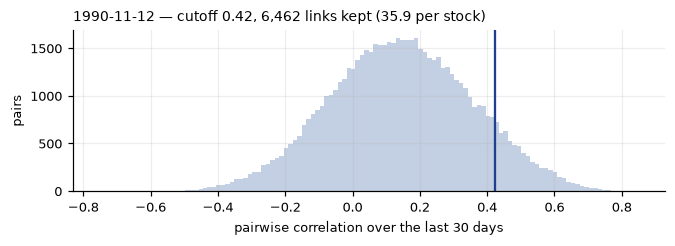

over the whole sample: 6,315 networks, 6,462 links each, mean degree 35.90
daily cutoff ranged 0.263 to 0.861 (highest on 1987-10-19)


In [3]:
prices = pd.read_parquet(os.path.join(ROOT, "data", "panel_clean.parquet"))
returns = np.load(os.path.join(ROOT, "data", "returns.npy"))
N, DELTA_T, F = returns.shape[0], 30, 0.10

w = 1200                                   # an ordinary day, far from any crisis
C = window_correlation(returns, w, DELTA_T)
tau, pairs, _ = threshold_window(C, target_edge_count(N, F), np.triu_indices(N, 1))
g = graph_from_pairs(pairs, N)
date = prices.index[w + DELTA_T]

fig, ax = plt.subplots(figsize=(6.2, 2.3))
ax.hist(C[np.triu_indices(N, 1)], bins=120, color="#c3cfe2", edgecolor="none")
ax.axvline(tau, color=C_REAL, lw=1.5)
ax.set_xlabel("pairwise correlation over the last 30 days"); ax.set_ylabel("pairs")
ax.set_title(f"{date.date()} — cutoff {tau:.2f}, {g.ecount():,} links kept "
             f"({2*g.ecount()/N:.1f} per stock)", loc="left", fontsize=9)
plt.tight_layout(); plt.show()

p2 = json.load(open(os.path.join(ROOT, "results", "phase2_networks.json")))
print(f"over the whole sample: {p2['n_windows']:,} networks, {p2['n_edges_per_day']:,} links each, "
      f"mean degree {p2['mean_degree']:.2f}")
print(f"daily cutoff ranged {p2['tau_min']:.3f} to {p2['tau_max']:.3f} "
      f"(highest on {p2['tau_argmax_date']})")

---
## 3 — Fig. 3: Black Monday

Louvain communities each day. **Modularity Q** scores the split: how many more links fall inside
communities than chance would give. The paper's Fig. 3 shows Q collapsing on 19 October 1987 and the
network breaking into a dense core plus a crowd of disconnected stocks. Colours are fixed to panel A's
communities so you can watch the same groups come apart.

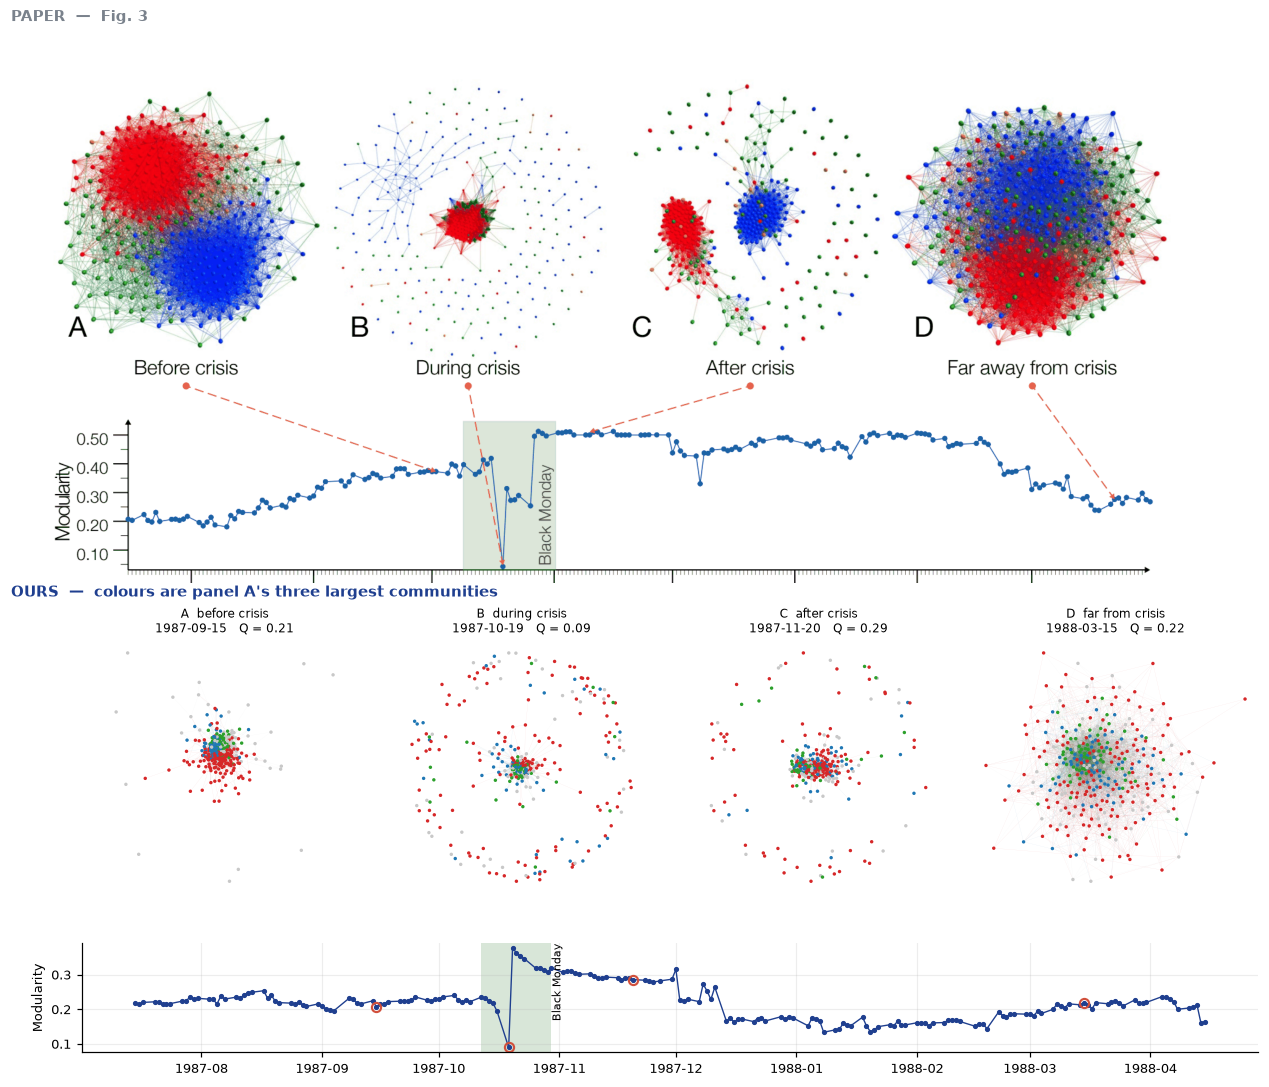

lowest modularity in 25 years : 0.090 on 1987-10-19
typical day                   : 0.220
communities on Black Monday   : 156  (typical day 9)


In [4]:
com = pd.read_parquet(os.path.join(ROOT, "results", "series", "communities.parquet"))
idx = com.index
edges = np.load(os.path.join(ROOT, "data", "edges.npy"), mmap_mode="r")
snaps = [("A  before crisis", "1987-09-15"), ("B  during crisis", "1987-10-19"),
         ("C  after crisis", "1987-11-20"), ("D  far from crisis", "1988-03-15")]
pos = {d: int(idx.get_indexer([pd.Timestamp(d)], method="nearest")[0]) for _, d in snaps}

random.seed(42); ig.set_random_number_generator(random)
gA = graph_from_pairs(edges[pos[snaps[0][1]]], N)
memb = np.asarray(gA.community_multilevel().membership)
top3 = list(pd.Series(memb).value_counts().index[:3])
pal = ["#d62728", "#1f77b4", "#2ca02c"]
colour = np.array([pal[top3.index(m)] if m in top3 else "#c8c8c8" for m in memb])

def layout(gg, seed=42):
    # each connected piece laid out on its own, then packed: the big pieces near
    # the centre, the fragments and loose stocks scattered around them
    rng = np.random.default_rng(seed)
    cc = gg.connected_components()
    memb_c, sizes = np.asarray(cc.membership), np.asarray(cc.sizes())
    xy = np.full((gg.vcount(), 2), np.nan)
    blobs = []
    for c in np.argsort(-sizes):
        v = np.flatnonzero(memb_c == c)
        if len(v) == 1:
            blobs.append((v, np.zeros((1, 2)), 0.0)); continue
        L = np.asarray(gg.subgraph(v).layout_fruchterman_reingold(niter=400).coords)
        L -= L.mean(0)
        L /= (np.percentile(np.hypot(L[:, 0], L[:, 1]), 85) + 1e-9)
        blobs.append((v, L, float(np.sqrt(len(v)))))
    big = [b for b in blobs if len(b[0]) >= 10]
    R = 0.0 if len(big) <= 1 else 2.1 * max(b[2] for b in big)
    ang = np.linspace(0, 2 * np.pi, max(len(big), 1), endpoint=False) + .4
    for i, (v, L, sc) in enumerate(big):
        c = R * np.array([np.cos(ang[i]), np.sin(ang[i])])
        xy[v] = c + L * sc
    done = np.isfinite(xy[:, 0])
    edge = 1.10 * (np.hypot(xy[done, 0], xy[done, 1]).max() if done.any() else 1.0)
    for v, L, sc in blobs:
        if len(v) >= 10: continue
        a, r = rng.uniform(0, 2 * np.pi), edge * (1.0 + .55 * np.sqrt(rng.uniform()))
        xy[v] = np.array([r * np.cos(a), r * np.sin(a)]) + L * max(sc, .35)
    return xy

def ours_fig3(sf):
    gs = sf.add_gridspec(2, 4, height_ratios=[2.3, 1.0], hspace=.28, wspace=.04,
                         left=.06, right=.99, top=.89, bottom=.12)
    for i, (lab, d) in enumerate(snaps):
        ax = sf.add_subplot(gs[0, i])
        gg = graph_from_pairs(edges[pos[d]], N)
        xy = layout(gg)
        for a, b in gg.get_edgelist():
            ax.plot(xy[[a, b], 0], xy[[a, b], 1], color=colour[a], lw=.15, alpha=.10, zorder=1)
        ax.scatter(xy[:, 0], xy[:, 1], s=5, c=colour, linewidths=0, zorder=2)
        ax.set_title(f"{lab}\n{idx[pos[d]].date()}   Q = {com['q_dyn'].iloc[pos[d]]:.2f}",
                     fontsize=8)
        ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([]); ax.grid(False)
        for sp in ax.spines.values(): sp.set_visible(False)
    ax = sf.add_subplot(gs[1, :])
    sel = (idx >= "1987-07-15") & (idx <= "1988-04-15")
    ax.plot(idx[sel], com["q_dyn"][sel], "-o", color=C_REAL, lw=.9, ms=2.4)
    ax.axvspan(pd.Timestamp("1987-10-12"), pd.Timestamp("1987-10-30"),
               color="#cfe0cf", alpha=.8, lw=0)
    ax.text(pd.Timestamp("1987-10-30"), ax.get_ylim()[1], " Black Monday",
            fontsize=7.5, va="top", rotation=90)
    for _, d in snaps:
        ax.plot([idx[pos[d]]], [com["q_dyn"].iloc[pos[d]]], "o", ms=6,
                mfc="none", mec="#d1503c", mew=1.4)
    ax.set_ylabel("Modularity")

compare("fig3", ours_fig3, h=4.6, w=11.5, note="colours are panel A's three largest communities")

print(f"lowest modularity in 25 years : {com['q_dyn'].min():.3f} on {com['q_dyn'].idxmin().date()}")
print(f"typical day                   : {com['q_dyn'].median():.3f}")
print(f"communities on Black Monday   : {int(com.loc['1987-10-19','k'])}  "
      f"(typical day {int(com['k'].median())})")

**Reproduced.** Modularity collapses to the lowest value of the whole 25 years on Black Monday, the
network shatters into one dense core plus a crowd of loose stocks, and it recovers within weeks — the
paper's shape exactly.

Two visible differences. Our Q runs lower throughout (~0.22 against the paper's ~0.40), and our networks
carry disconnected stocks on ordinary days too, where the paper's panel A is a single connected blob.
Both follow from the larger, sparser sample.

---
## 4 — Fig. 4: 25 years of modularity and path length

Same two series across the whole sample, crises shaded. The paper dates only Black Monday exactly, so
the bands are conventional dates for the events it names.

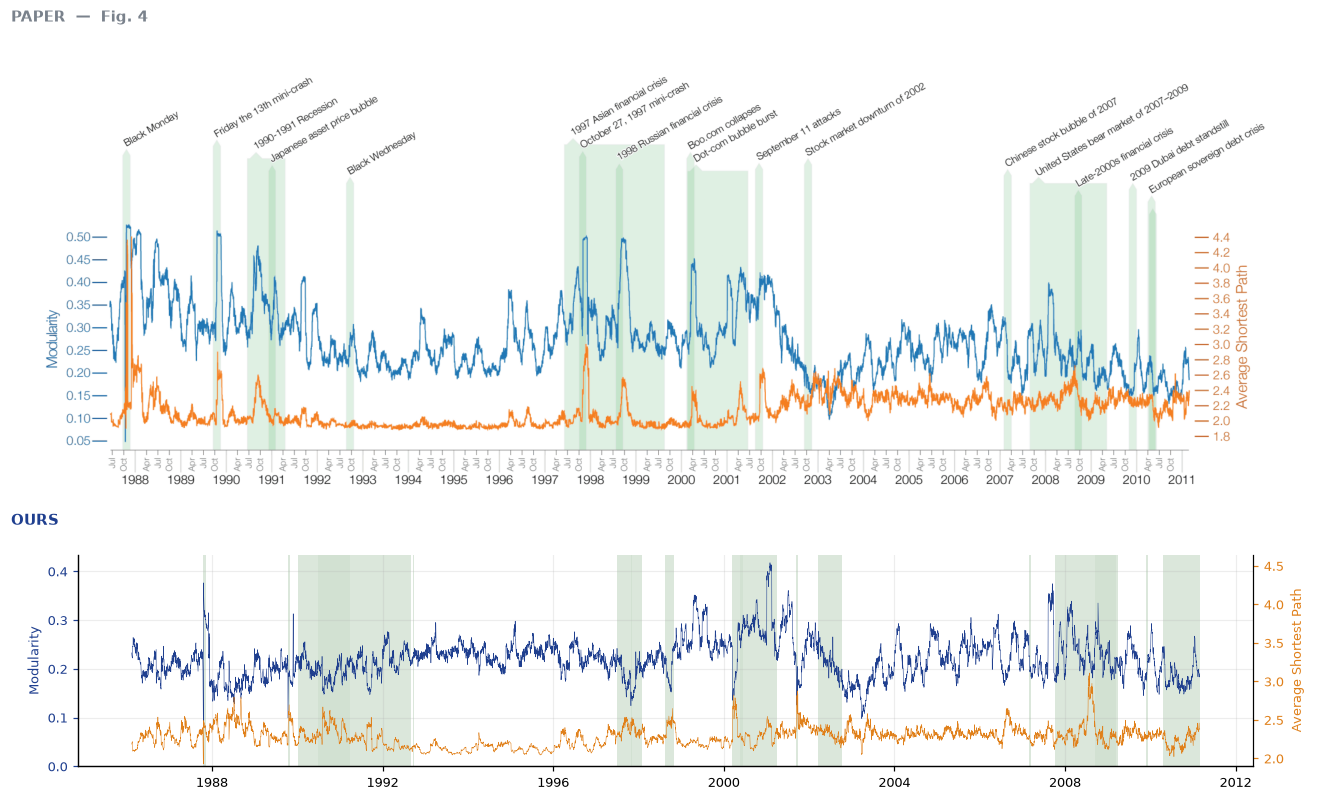

modularity   paper range ~0.05-0.52   ours 0.09-0.42
path length  paper range ~1.8-4.4     ours 1.93-3.11


In [5]:
s = P.load_series()

def ours_fig4(sf):
    ax = sf.subplots()
    sf.subplots_adjust(left=.055, right=.945, top=.86, bottom=.16)
    crisis_bands(ax)
    ax.plot(idx, com["q_dyn"], color=C_REAL, lw=.35)
    ax.set_ylabel("Modularity", color=C_REAL); ax.tick_params(axis="y", colors=C_REAL)
    a2 = ax.twinx(); a2.grid(False)
    a2.plot(s.index, s["real_path_length"], color=C_COMM, lw=.35)
    a2.set_ylabel("Average Shortest Path", color=C_COMM); a2.tick_params(axis="y", colors=C_COMM)
    a2.spines["right"].set_visible(True)
    # push modularity into the top half and path length into the bottom, as the paper does
    q, pl = com["q_dyn"], s["real_path_length"]
    ax.set_ylim(0, q.max() * 1.04)
    a2.set_ylim(pl.min() - .03, pl.min() + 2.3 * (pl.max() - pl.min()))

compare("fig4", ours_fig4, h=2.5)
print(f"modularity   paper range ~0.05-0.52   ours {com['q_dyn'].min():.2f}-{com['q_dyn'].max():.2f}")
print(f"path length  paper range ~1.8-4.4     ours {s['real_path_length'].min():.2f}-"
      f"{s['real_path_length'].max():.2f}")

**Reproduced in shape, not in level.** Both series spike at the same crises and both step down around
2002. Our modularity runs about 0.10 lower throughout, again a consequence of the larger, sparser sample.

---
## 5 — Fig. 5: do the communities last?

Modularity can move for two reasons: the groups changed, or the same groups tightened. To separate them
the paper scores Q three ways with the same formula and three different groupings —

- **dynamical**: re-find the communities every day,
- **fixed**: find them once on day 1 and never again,
- **lagged**: use the communities from 100 trading days ago.

If fixed and lagged track the dynamical curve, membership is stable. If they fall to zero, it is churning.

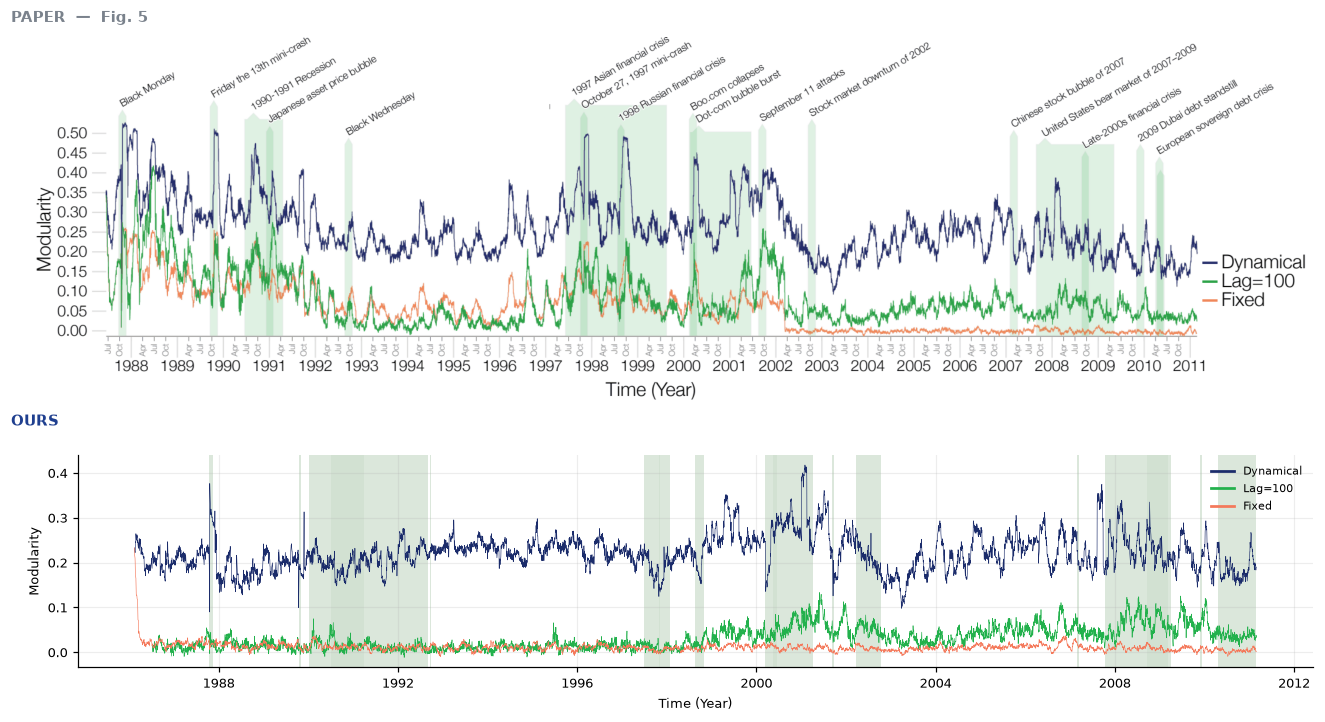

25-year mean       dynamical 0.222   lagged 0.031   fixed 0.011
fixed Q, first year of sample  0.031
fixed Q, last year of sample   0.004


In [6]:
def ours_fig5(sf):
    ax = sf.subplots()
    sf.subplots_adjust(left=.055, right=.99, top=.86, bottom=.16)
    crisis_bands(ax)
    ax.plot(idx, com["q_dyn"],    color="#1b2c6b", lw=.4, label="Dynamical")
    ax.plot(idx, com["q_lagged"], color="#22b14c", lw=.4, label="Lag=100")
    ax.plot(idx, com["q_fixed"],  color="#f4795b", lw=.4, label="Fixed")
    ax.set_ylabel("Modularity"); ax.set_xlabel("Time (Year)")
    legend(ax, loc="upper right")

compare("fig5", ours_fig5, h=2.5)
print(f"25-year mean       dynamical {com['q_dyn'].mean():.3f}   "
      f"lagged {com['q_lagged'].mean():.3f}   fixed {com['q_fixed'].mean():.3f}")
print(f"fixed Q, first year of sample  {com['q_fixed'][:250].mean():.3f}")
print(f"fixed Q, last year of sample   {com['q_fixed'][-250:].mean():.3f}")

**Not reproduced.** Both agree on the ordering — fixed and lagged sit below dynamical — so a modularity
spike really is the market re-arranging which stocks group together, not just tightening existing groups.

They disagree on size, and it is visible at a glance. The paper's fixed curve stays clear of zero for
25 years; ours is on the floor within the first year. The paper's communities persist. Ours do not.

---
## 6 — The two random networks

**Community model (Eq. 2).** Count Π_αβ, the links between communities α and β; divide by how many pairs
*could* have been linked to get a probability π_αβ; then start from unconnected stocks, put them in
communities of the observed sizes, and flip a π-weighted coin for every pair.

$$\pi_{\alpha\beta}=\frac{2\,\Pi_{\alpha\alpha}}{|\alpha|(|\alpha|-1)}\ \text{ if }\alpha=\beta,\qquad
\pi_{\alpha\beta}=\frac{\Pi_{\alpha\beta}}{|\alpha||\beta|}\ \text{ otherwise.}$$

**Degree model (configuration model).** Keep each stock's link count, shuffle everything else.

One realisation of each, per day, as the paper describes.

In [7]:
store = MixingStore.load(os.path.join(ROOT, "data", "mixing.npz"))
Pi, sizes = store[w]
g_comm, _ = community_graph(sizes, Pi, np.random.default_rng(42), N)
g_conf, _ = configuration_graph(g, 49)

print(f"one day ({date.date()})\n")
print(pd.DataFrame({
    "real network":    [g.ecount(), f"{np.mean(g.degree()):.1f}",
                        f"{g.modularity(g.community_multilevel().membership):.3f}"],
    "community model": [g_comm.ecount(), f"{np.mean(g_comm.degree()):.1f}",
                        f"{g_comm.modularity(g_comm.community_multilevel().membership):.3f}"],
    "degree model":    [g_conf.ecount(), f"{np.mean(g_conf.degree()):.1f}",
                        f"{g_conf.modularity(g_conf.community_multilevel().membership):.3f}"],
}, index=["links", "links per stock", "modularity"]).to_string())
print(f"\n{len(sizes)} communities that day; the community model is described by "
      f"{len(sizes) + len(sizes)*(len(sizes)+1)//2} numbers, the degree model by {N}")

one day (1990-11-12)

                real network community model degree model
links                   6462            6419         6462
links per stock         35.9            35.7         35.9
modularity             0.174           0.176        0.097

14 communities that day; the community model is described by 119 numbers, the degree model by 360


---
## 7 — Eight measurements, three networks, every day

Modularity, average shortest path, assortativity, transitivity, average betweenness, clique number,
rich-club coefficient, average matching index — on the real network and both models, for all ~6,300 days.

Two places the paper is silent, and what was chosen:

- **Path length when the network is in pieces.** Unreachable pairs are skipped, not counted as infinite.
- **Matching index.** The paper cites Costa et al. (2007), where it is defined *per link*. Averaged over
  links it lands at ~0.19, inside the 0.10–0.40 range the paper's own axis shows; averaged over all pairs
  it lands at ~0.065, far outside it.

Cached, so a re-run is instant.

In [8]:
rep = P.run(verbose=True)
tab = P.load_table()
s = P.load_series()
print(f"\n{rep['n_windows']:,} days x 3 networks in {rep['elapsed_sec']:.0f}s, seed {rep['seed']}")

[cached] /Users/jash/Financial_networks_project/paper3_market_modularity/results/paper_only.json — pass force=True to rebuild.

6,315 days x 3 networks in 164s, seed 42


### How to read the next eight comparisons

Each is one measure, laid out exactly like the paper's panel: three time series on the left, and on the
right a scatter of the real value against each model's. Dark points are before 2002, light after — the
paper's own split. The diagonal is perfect agreement.

The boxes carry the two numbers the paper reports:

- **χ²** — average squared difference. Small = the model lands on the same *value*.
- **ρ** — Pearson correlation. High = the model *moves the same way*, even at a different level.

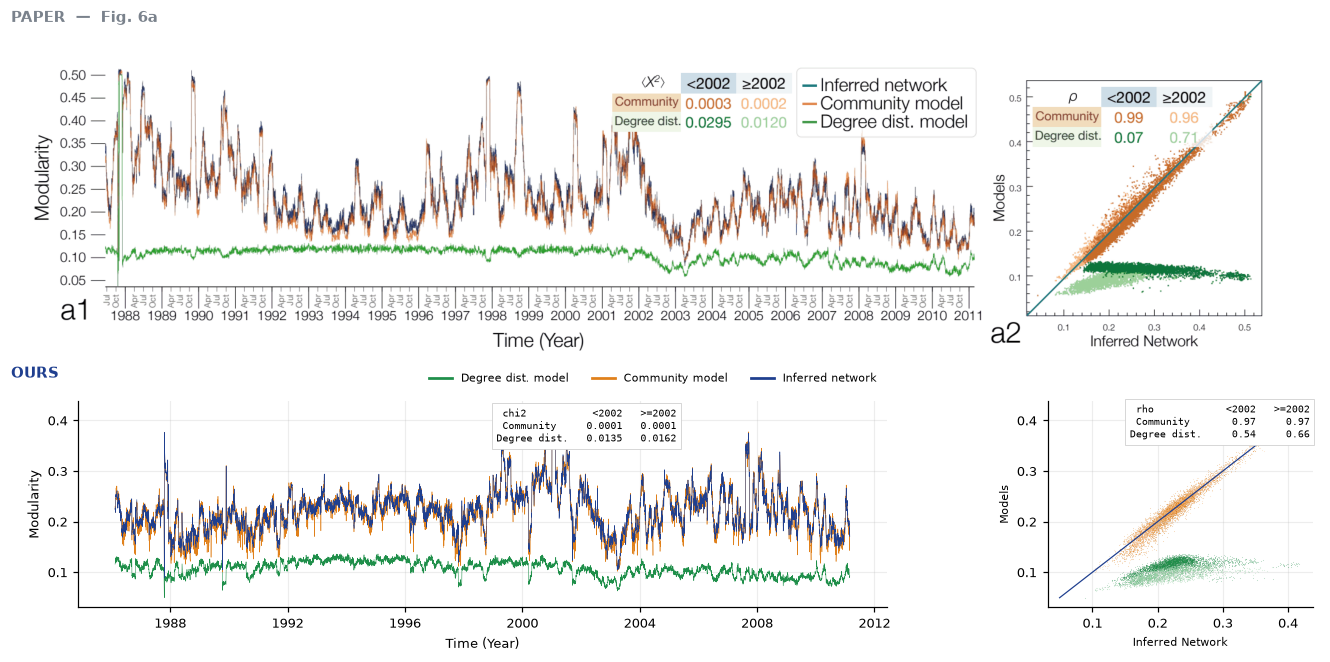

In [9]:
def _box(ax, m, field, title, fmt, xy):
    q = tab[tab.measure == m].set_index(["model", "era"])
    txt = (f"{title:<11}{'<2002':>9}{'>=2002':>9}\n"
           + "\n".join(f"{MODEL[k]:<11}{fmt(q.loc[(k,'pre'), field]):>9}"
                       f"{fmt(q.loc[(k,'post'), field]):>9}" for k in ("comm", "conf")))
    ax.text(*xy, txt, transform=ax.transAxes, fontsize=6.6, family="monospace",
            va="top", ha="right", bbox=dict(fc="white", ec="#cccccc", lw=.5, pad=3))

def measure_row(m, fmt):
    def build(sf):
        ax, sc = sf.subplots(1, 2, width_ratios=[3.05, 1.0])
        sf.subplots_adjust(left=.055, right=.99, top=.88, bottom=.20, wspace=.30)
        for k, col in (("conf", C_CONF), ("comm", C_COMM), ("real", C_REAL)):
            ax.plot(s.index, s[f"{k}_{m}"], color=col, lw=.35,
                    label={"real": "Inferred network", "comm": "Community model",
                           "conf": "Degree dist. model"}[k])
        ax.set_ylabel(LABEL[m]); ax.set_xlabel("Time (Year)")
        legend(ax, loc="upper right", ncol=3, bbox_to_anchor=(1.0, 1.19))
        _box(ax, m, "chi2", "chi2", fmt, (.74, .97))

        pre = s.index.year < 2002
        for k, dark, light in (("comm", C_COMM, C_COMM_L), ("conf", C_CONF, C_CONF_L)):
            sc.scatter(s[f"real_{m}"][pre],  s[f"{k}_{m}"][pre],  s=.5, c=dark,  alpha=.30, lw=0)
            sc.scatter(s[f"real_{m}"][~pre], s[f"{k}_{m}"][~pre], s=.5, c=light, alpha=.30, lw=0)
        lo = float(np.nanmin([s[f"{k}_{m}"].min() for k in ("real", "comm", "conf")]))
        hi = float(np.nanmax([s[f"{k}_{m}"].max() for k in ("real", "comm", "conf")]))
        sc.plot([lo, hi], [lo, hi], color=C_REAL, lw=.8)
        sc.set_xlabel("Inferred Network", fontsize=7.5); sc.set_ylabel("Models", fontsize=7.5)
        _box(sc, m, "rho", "rho", lambda v: f"{v:.2f}", (.99, .99))
    return build

f4 = lambda v: f"{v:.4f}"
f0 = lambda v: f"{v:.0f}"
compare("fig6_a", measure_row("modularity", f4), h=2.5)

**Modularity — the headline claim, reproduced.** The community model tracks the real network almost
perfectly (ρ 0.97/0.97 against the paper's 0.99/0.96) and the degree model sits on a flat floor near 0.10,
the same picture the paper draws.

One cell differs: the degree model's pre-2002 correlation is 0.54 here against the paper's 0.07. In the
paper the green cloud is a flat horizontal band; in ours it slopes. That matters, because the degree model
is the yardstick — the community model looks impressive in proportion to how badly the degree model does.

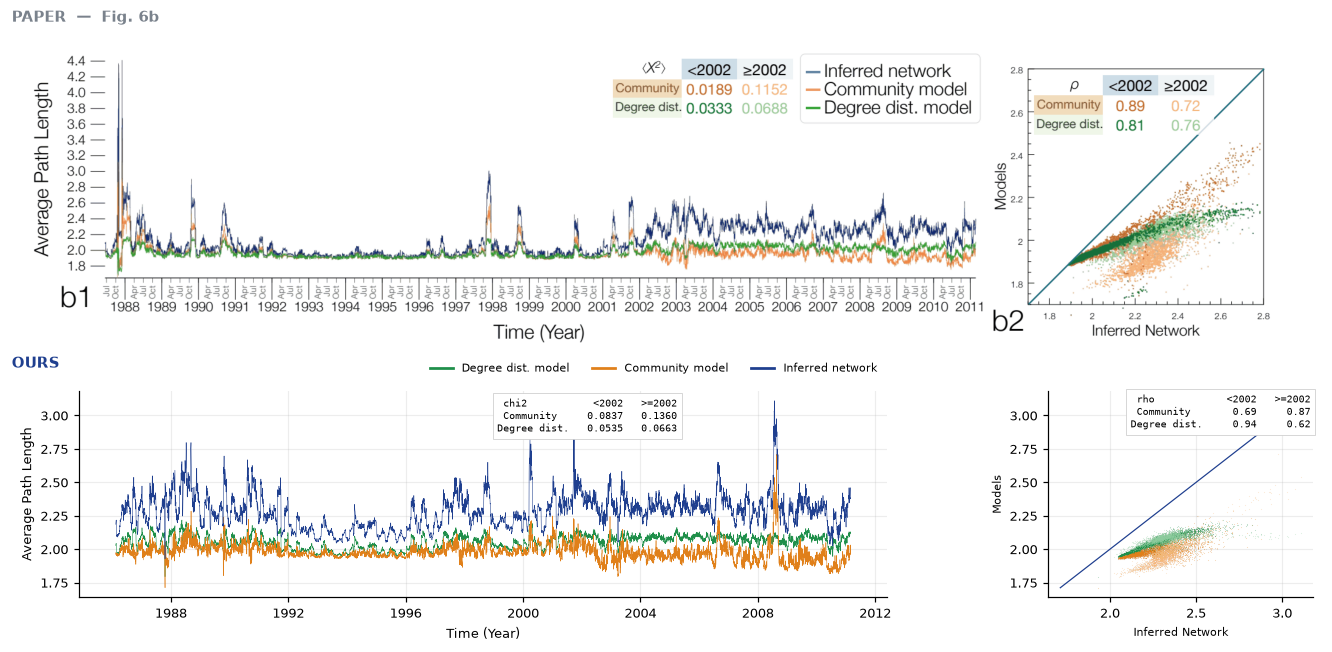

In [10]:
compare("fig6_b", measure_row("path_length", f4), h=2.5)

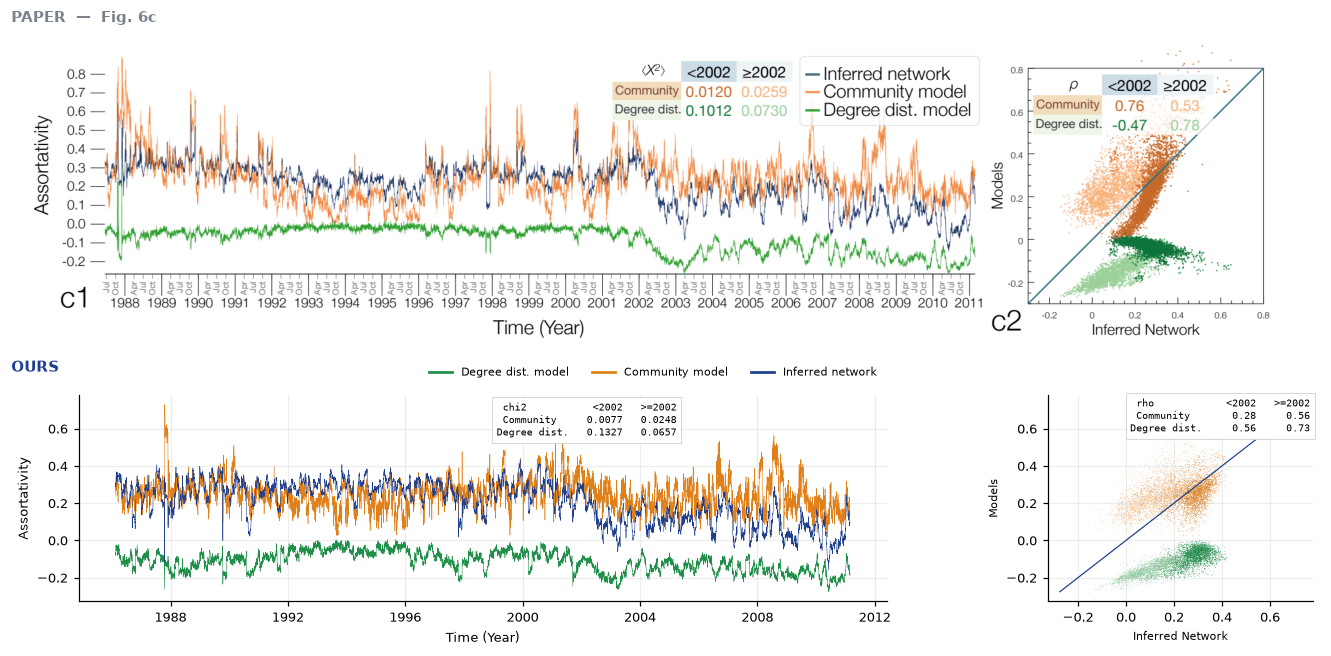

In [11]:
compare("fig6_c", measure_row("assortativity", f4), h=2.5)

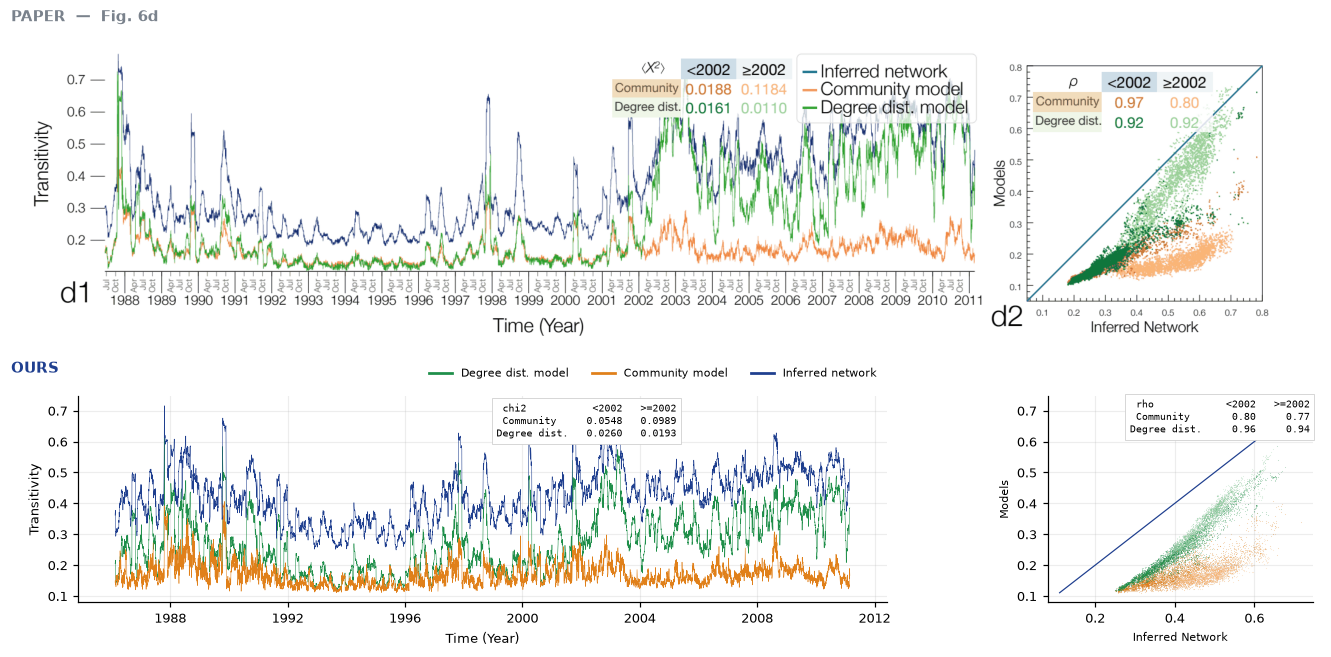

In [12]:
compare("fig6_d", measure_row("transitivity", f4), h=2.5)

**Path length, transitivity — reproduced.** Same shapes, same ordering, χ² within the same order of
magnitude.

**Assortativity — two cells differ, both before 2002.** The paper's degree model *anti*-correlates with
the real network (ρ = −0.47); ours correlates at +0.56. And the paper's community model reaches 0.76
where ours manages 0.28. Both differences run the same way: they narrow the community model's lead.

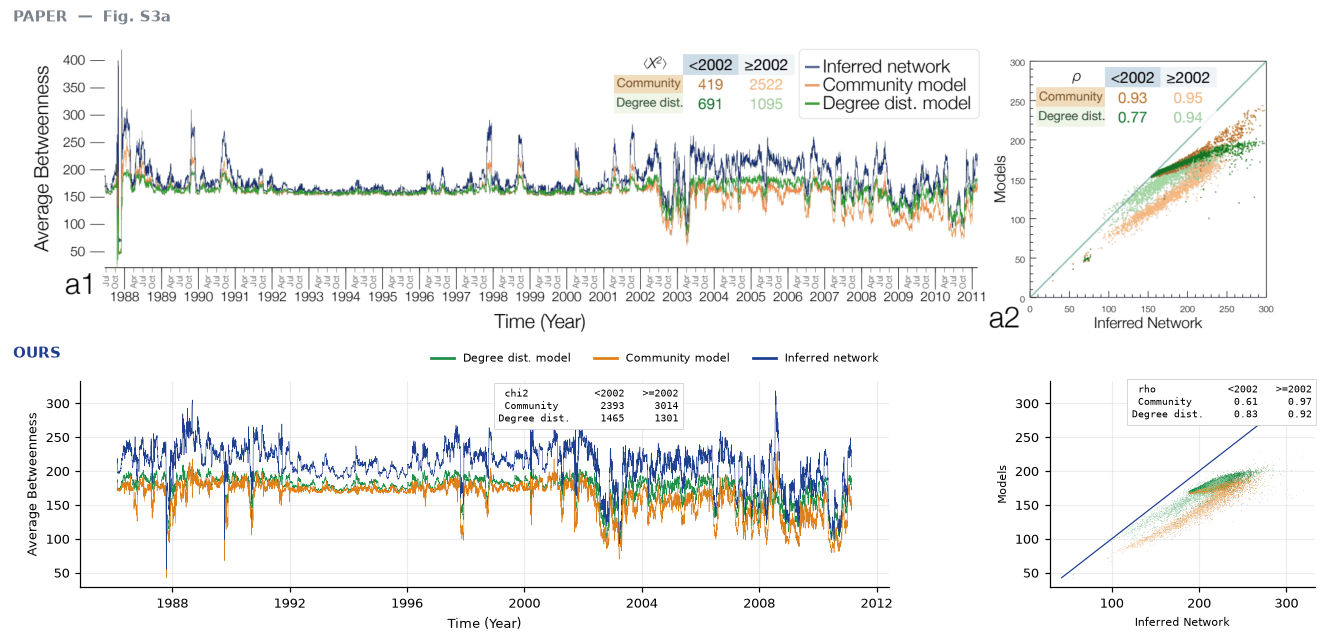

In [13]:
compare("figS3_a", measure_row("betweenness", f0), h=2.5)

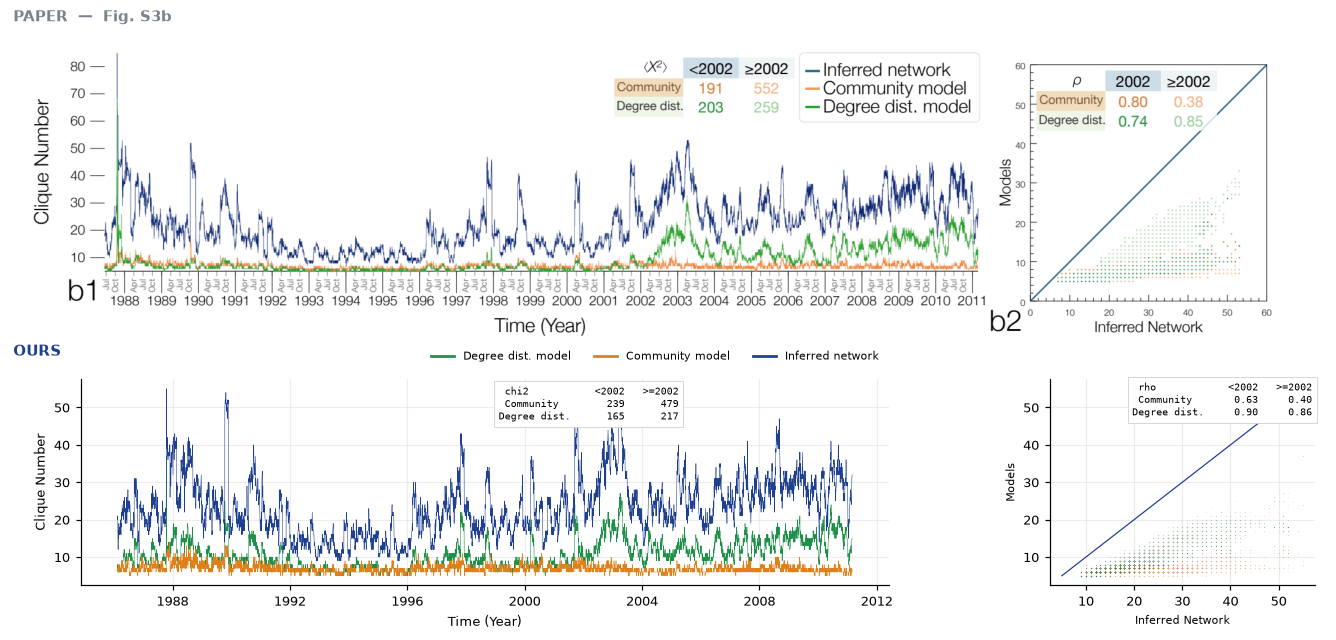

In [14]:
compare("figS3_b", measure_row("clique_number", f0), h=2.5)

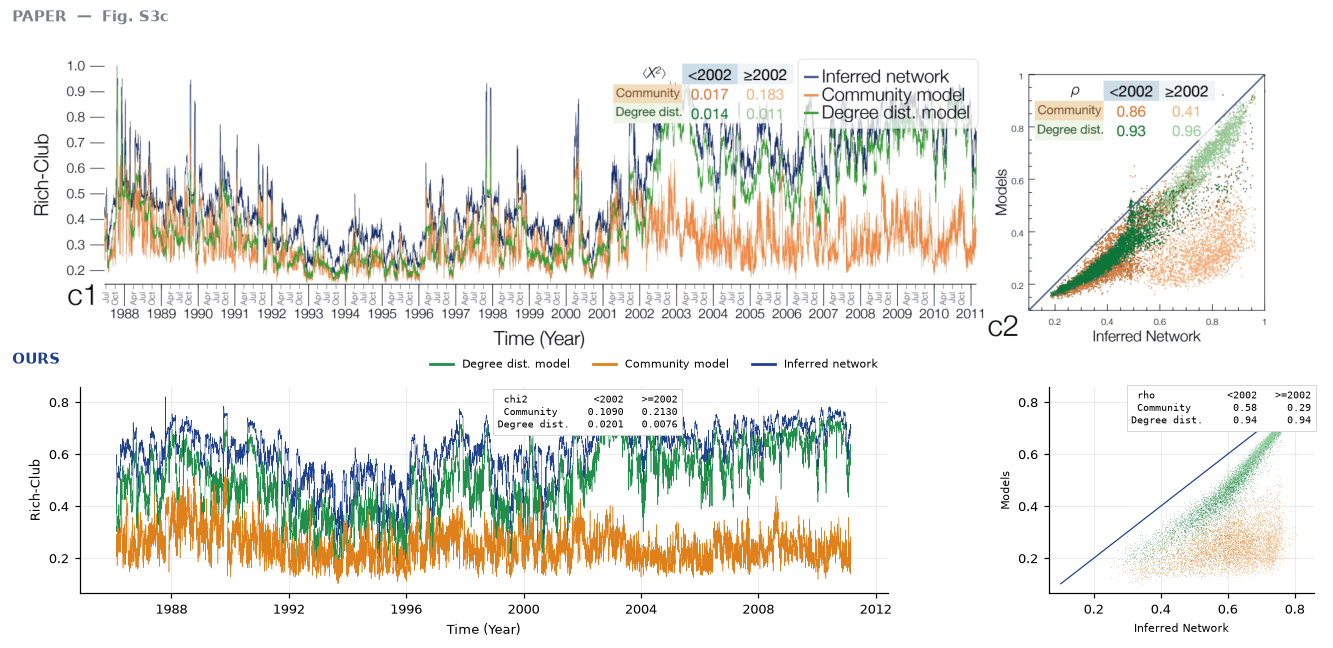

In [15]:
compare("figS3_c", measure_row("rich_club", f4), h=2.5)

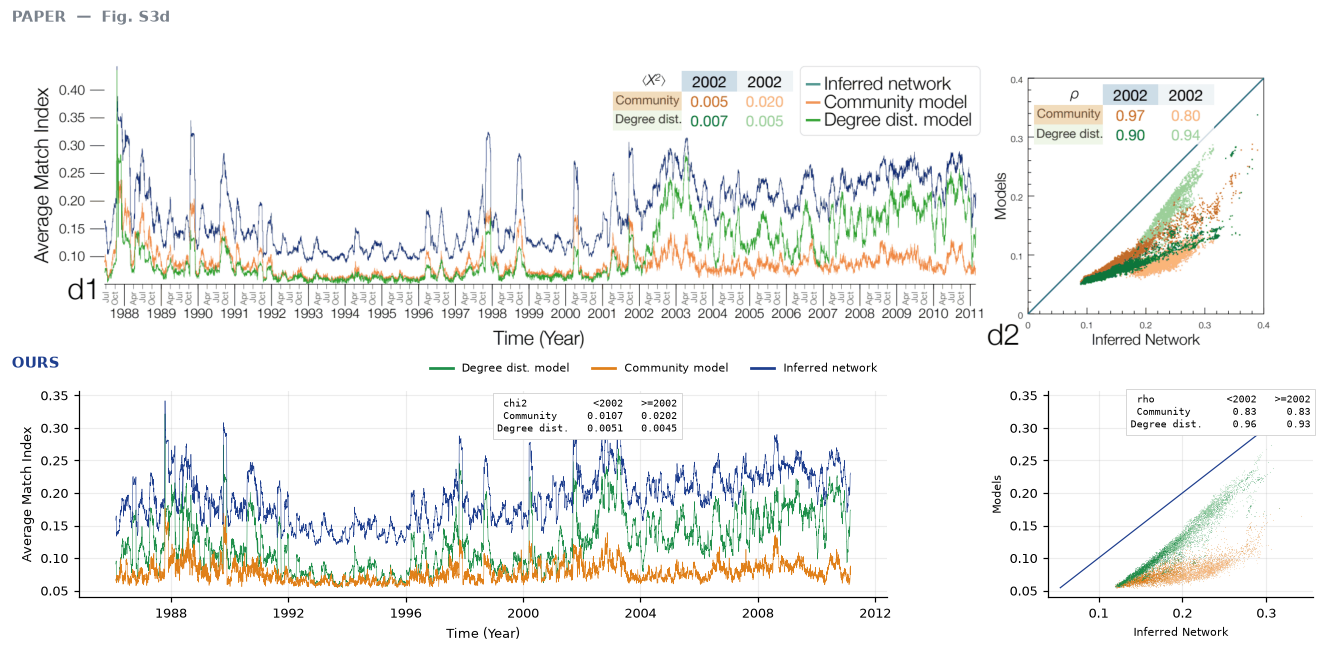

In [16]:
compare("figS3_d", measure_row("matching_index", f4), h=2.5)

**All four supplementary measures reproduce in shape.** Betweenness, clique number and matching index sit
in the paper's ranges and rank the two models the same way. Rich club is the loosest fit: our curve is
noisier and the community model's pre-2002 correlation comes out at 0.58 against the paper's 0.86.

---
## 8 — Fig. 7: all eight measures at once (PCA)

PCA squeezes the eight measures into two numbers per network. If the community model's cloud sits on the
real one, it reproduces the market's whole topological signature at once.

The paper reads this plot in a specific way: *"the first principal component is strongly related to
changes in the network structure along time... therefore, the models should be compared according to the
second principal component (PCA2)."*

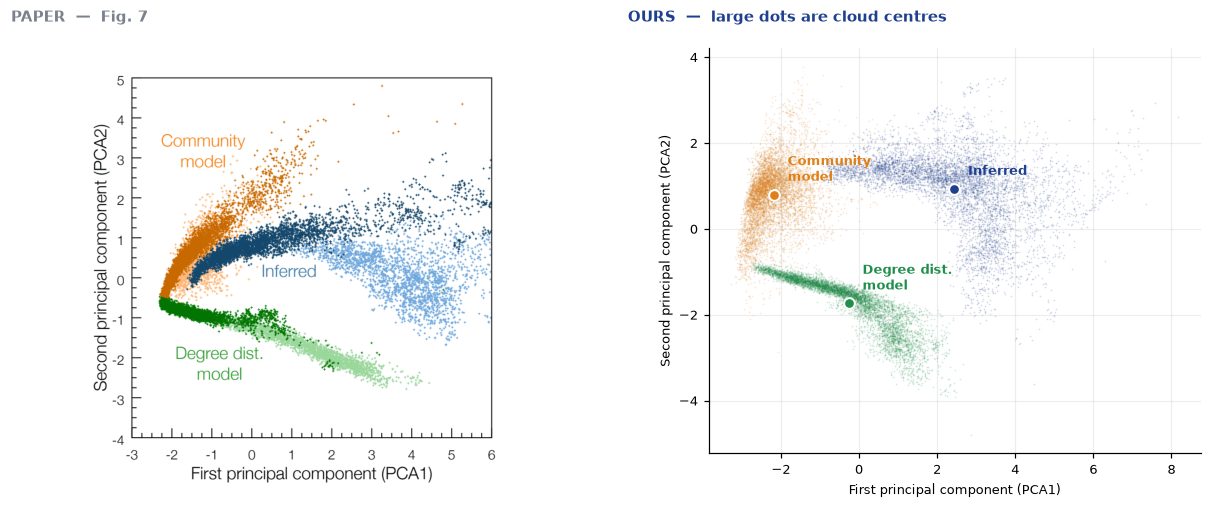

distance from the inferred cloud's centre:
  Community      along PCA2 (the paper's criterion)  0.14     whole plane  4.62
  Degree dist.   along PCA2 (the paper's criterion)  2.67     whole plane  3.80


In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X = np.vstack([np.column_stack([s[f"{f}_{m}"] for m in P.MEASURES])
               for f in ("real", "comm", "conf")])
fam = np.repeat(["real", "comm", "conf"], len(s))
ok = np.isfinite(X).all(1)
Z = PCA(n_components=2).fit_transform(StandardScaler().fit_transform(X[ok])); fam = fam[ok]

def ours_fig7(sf):
    ax = sf.subplots()
    sf.subplots_adjust(left=.14, right=.97, top=.92, bottom=.12)
    for f, col, lab in (("real", C_REAL, "Inferred"), ("comm", C_COMM, "Community\nmodel"),
                        ("conf", C_CONF, "Degree dist.\nmodel")):
        ax.scatter(Z[fam == f, 0], Z[fam == f, 1], s=1.2, c=col, alpha=.18, lw=0)
        c = Z[fam == f].mean(0)
        ax.plot(*c, "o", ms=7, mfc=col, mec="white", mew=1.3, zorder=5)
        ax.annotate(lab, c, textcoords="offset points", xytext=(9, 9),
                    color=col, fontsize=8.5, fontweight="bold")
    ax.set_xlabel("First principal component (PCA1)")
    ax.set_ylabel("Second principal component (PCA2)")

compare_lr("fig7", ours_fig7, note="large dots are cloud centres")

cen = {f: Z[fam == f].mean(0) for f in ("real", "comm", "conf")}
print("distance from the inferred cloud's centre:")
for f in ("comm", "conf"):
    print(f"  {MODEL[f]:<14} along PCA2 (the paper's criterion) {abs(cen[f][1]-cen['real'][1]):5.2f}"
          f"     whole plane {np.hypot(*(cen[f]-cen['real'])):5.2f}")

**Reproduced.** Three separated arcs in the same arrangement, with the community model's cloud closer to
the inferred one along PCA2 — the axis the paper says to judge on.

---
## 9 — All 32 published numbers

8 measures × 2 models × 2 periods, each with a χ² and a ρ. Below: every ρ plotted against the paper's,
every χ² against the paper's, then the full table.

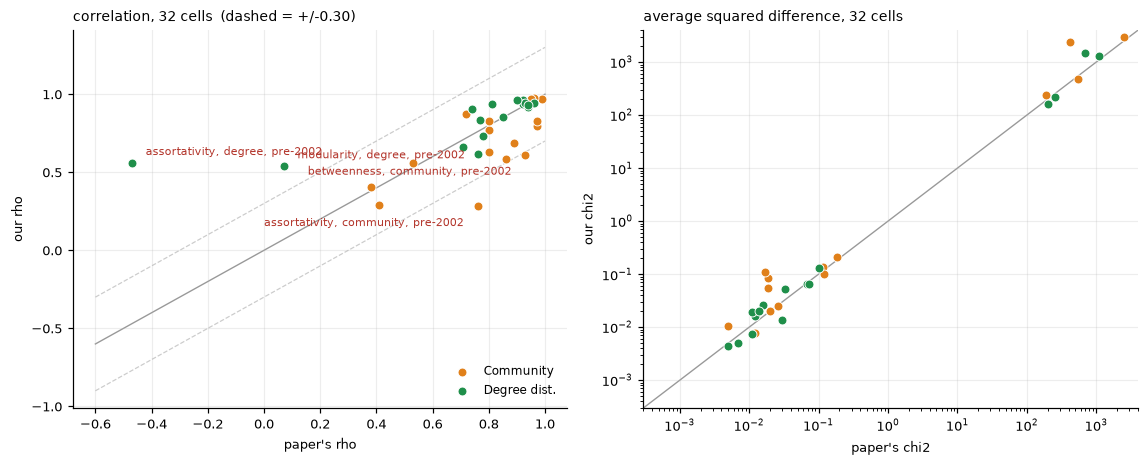

across all 32 correlations:  mean gap 0.140   within 0.10 56%   within 0.30 88%   same sign 97%


In [18]:
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.5, 4.3))
for k, col in (("comm", C_COMM), ("conf", C_CONF)):
    q = tab[tab.model == k]
    a1.scatter(q["paper_rho"], q["rho"], s=34, c=col, label=MODEL[k], zorder=3,
               edgecolors="white", linewidths=.6)
    a2.scatter(q["paper_chi2"], q["chi2"], s=34, c=col, zorder=3,
               edgecolors="white", linewidths=.6)
a1.plot([-.6, 1], [-.6, 1], color="#999999", lw=.9, zorder=1)
for d in (.3, -.3):
    a1.plot([-.6, 1], [-.6 + d, 1 + d], color="#cccccc", lw=.8, ls="--", zorder=1)
short = {"comm": "community", "conf": "degree"}
for n, (_, r) in enumerate(tab[tab.rho_delta.abs() > .30].iterrows()):
    right = r["paper_rho"] < .6
    dy = 5 if n % 2 == 0 else -13
    a1.annotate(f"{r['measure']}, {short[r['model']]}, {r['era']}-2002",
                (r["paper_rho"], r["rho"]), textcoords="offset points",
                xytext=((9, dy) if right else (-9, dy)), fontsize=7.2, color="#b3352b",
                ha="left" if right else "right")
a1.set_xlabel("paper's rho"); a1.set_ylabel("our rho")
a1.set_title("correlation, 32 cells  (dashed = +/-0.30)", loc="left", fontsize=9)
a1.legend(frameon=False, fontsize=8, loc="lower right")

lim = [3e-4, 4e3]
a2.plot(lim, lim, color="#999999", lw=.9, zorder=1)
a2.set_xscale("log"); a2.set_yscale("log"); a2.set_xlim(lim); a2.set_ylim(lim)
a2.set_xlabel("paper's chi2"); a2.set_ylabel("our chi2")
a2.set_title("average squared difference, 32 cells", loc="left", fontsize=9)
plt.tight_layout(); plt.show()

r = rep["rho"]
print(f"across all 32 correlations:  mean gap {r['mae_vs_paper']:.3f}   "
      f"within 0.10 {r['within_0_10']:.0%}   within 0.30 {r['within_0_30']:.0%}   "
      f"same sign {r['sign_agreement']:.0%}")

In [19]:
print(f"{'measure':<16}{'model':<14}{'era':<6}{'chi2 ours':>11}{'chi2 paper':>11}"
      f"{'rho ours':>10}{'rho paper':>10}{'delta':>8}")
print("-" * 86)
for _, x in tab.iterrows():
    flag = "  <-- differs" if abs(x["rho_delta"]) > .30 else ""
    print(f"{x['measure']:<16}{MODEL[x['model']]:<14}{x['era']:<6}"
          f"{x['chi2']:>11.4g}{x['paper_chi2']:>11.4g}"
          f"{x['rho']:>10.3f}{x['paper_rho']:>10.2f}{x['rho_delta']:>+8.2f}{flag}")

h = rep["head_to_head"]
print(f"\nwhich model is closer to the real network, over 16 measure x period cells?")
print(f"{'':<20}{'community wins':>16}{'degree wins':>14}")
for lab, key in (("by chi2  paper", "paper_community_wins_chi2"), ("by chi2  ours", "ours_community_wins_chi2"),
                 ("by rho   paper", "paper_community_wins_rho"),  ("by rho   ours", "ours_community_wins_rho")):
    print(f"{lab:<20}{h[key]:>16}{16-h[key]:>14}")

measure         model         era     chi2 ours chi2 paper  rho ours rho paper   delta
--------------------------------------------------------------------------------------
modularity      Community     pre     0.0001208     0.0003     0.969      0.99   -0.02
modularity      Community     post    0.0001019     0.0002     0.974      0.96   +0.01
modularity      Degree dist.  pre       0.01352     0.0295     0.540      0.07   +0.47  <-- differs
modularity      Degree dist.  post      0.01623      0.012     0.664      0.71   -0.05
path_length     Community     pre       0.08372     0.0189     0.689      0.89   -0.20
path_length     Community     post        0.136     0.1152     0.870      0.72   +0.15
path_length     Degree dist.  pre        0.0535     0.0333     0.939      0.81   +0.13
path_length     Degree dist.  post      0.06631     0.0688     0.617      0.76   -0.14
assortativity   Community     pre      0.007697      0.012     0.283      0.76   -0.48  <-- differs
assortativity   C

---
## 10 — Verdict

**Reproduced**

- Fixed density holds the mean degree constant every single day.
- Black Monday: modularity collapses to a 25-year low, the network shatters, it recovers in weeks (Fig. 3).
- Modularity and path length spike at the same crises and step down at 2002 (Fig. 4).
- The community model tracks the real network's modularity almost perfectly — the paper's headline claim.
- The degree model's modularity sits on a flat floor near 0.10, as the paper draws but never states.
- Three separated PCA arcs, community model nearest along PCA2 (Fig. 7).
- 88% of the 32 published correlations land within 0.30; 97% share the paper's sign.

**Not reproduced**

- **Community persistence (Fig. 5).** The paper's fixed and lagged modularity stay well clear of zero for
  25 years; ours collapse within the first. The paper's groups last; ours churn.
- **Four cells** differ by more than 0.30, all before 2002: modularity and assortativity for the degree
  model, which tracks the real network *more* closely here than in the paper, and assortativity and
  betweenness for the community model, which tracks it *less* closely. Both differences run the same
  way — the community model's lead is smaller in this run. It wins 4 of the 16 χ² cells against the
  paper's 8, and 4 of the 16 ρ cells against the paper's 9.

**Cannot be matched.** The stock list. The paper's 348 NYSE names came from a 2015 snapshot of 3,799
listings that no longer exists, and any list built today is filtered by survival. Everything here rests on
a different, larger sample of the same market over the same years.

*Paper figures are cropped from `docs/1501.05040v3.pdf` by `docs/extract_paper_figs.py`, for comparison only.*